In [1]:
import torch
from torch import nn, optim
import torch.nn as nn
import math
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, head_count):
        super(TransformerBlock, self).__init__()
        self.attention = nn.MultiheadAttention(embed_size, head_count, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, 4*embed_size),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(4*embed_size, embed_size)
        )
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x_norm = self.norm1(x)
        attention_output, _ = self.attention(x_norm,x_norm,x_norm)
        x = x + self.dropout(attention_output)
        x_norm = self.norm2(x)
        ff_output = self.feed_forward(x_norm)
        x = x + self.dropout(ff_output)
        return x

class Transformer_learnable(nn.Module):
    def __init__(self, vocab_size, posi_size, embed_size, num_layers, head_count, LB):
        super(Transformer_learnable, self).__init__()
        self.embed_size = embed_size
        self.LB = LB

        # embed each z_bit ∈ {0,1}
        self.z_bit_embed = nn.Embedding(2, embed_size)
        # project flattened z_emb → one context token
        self.z_ffn = nn.Sequential(
            nn.Linear(LB * embed_size, embed_size),
            nn.ReLU()
        )

        # embedding for P/b tokens
        self.word_embedding = nn.Embedding(vocab_size, embed_size)
        self.position_embedding = nn.Embedding(posi_size, embed_size)

        # Transformer layers
        self.layers = nn.ModuleList(
            [TransformerBlock(embed_size, head_count) for _ in range(num_layers)]
        )

        # predict next b ∈ {0,1}
        self.fc_out = nn.Linear(embed_size, 2)
        self.tokendrop = nn.Dropout(0.25)

    def forward(self, inputs, mask=None):
        """
        inputs: LongTensor of shape (B, LB + T)
        """
        device = inputs.device
        B, total_len = inputs.size()

        # 1) embed z_bits
        z_bits = inputs[:, :self.LB].long()               # (B, LB)
        z_emb  = self.z_bit_embed(z_bits.to(device))      # (B, LB, D)
        z_flat = z_emb.flatten(start_dim=1)                # (B, LB*D)
        para_context = self.z_ffn(z_flat).unsqueeze(1)    # (B, 1, D)

        # 2) embed interleaved tokens
        token_inputs = inputs[:, self.LB:].long()         # (B, T)
        token_emb    = self.word_embedding(token_inputs.to(device))  # (B, T, D)
        positions    = torch.arange(token_inputs.size(1), device=device) \
                               .unsqueeze(0).expand(B, -1)         # (B, T)
        pos_emb      = self.position_embedding(positions)          # (B, T, D)
        token_emb    = token_emb + pos_emb                       # (B, T, D)
        token_emb    = self.tokendrop(token_emb)                  # 如果要用 dropout

        # 3) concat
        out = torch.cat((para_context, token_emb), dim=1)         # (B, 1+T, D)

        # 4) transformer layers
        for layer in self.layers:
            out = layer(out)

        # 5) predict next b
        logits = self.fc_out(out[:, -1, :])                       # (B, 2)
        return logits


def generate_with_z(z_bits, model, LA, sample_size, device):
    """
    Args:
        z_bits: 1D LongTensor of shape (LB,)  e.g. torch.tensor([0,1,0,1,1,0,0,1])
        model: your Transformer_learnable instance
        LA: number of subsystem A qubits (e.g. 2)
        sample_size: how many sequences to generate
        device: torch.device
    Returns:
        outputs: LongTensor of shape (sample_size, LB + 2*LA)
                 each row = [z1..z8, P1, b1, P2, b2]
    """
    LB = z_bits.numel()
    T = 2 * LA
    # 1) 初始化 outputs tensor
    outputs = torch.zeros((sample_size, LB + T), dtype=torch.long, device=device)
    # 2) 填入相同的 z_bits
    z_expand = z_bits.to(device).unsqueeze(0).expand(sample_size, LB)
    outputs[:, :LB] = z_expand

    # 3) 逐位生成 (P_i, b_i)
    for i in range(LA):
        P_col = LB + 2 * i
        b_col = P_col + 1

        # 隨機選一個 P ∈ {2,3,4}
        outputs[:, P_col] = torch.randint(2, 5, (sample_size,), device=device)

        # 呼叫 model，傳入到目前為止的 prefix
        logits = model(outputs[:, :P_col+1], device)  # shape (sample_size, 2)
        probs = F.softmax(logits, dim=1)

        # 從 Bernoulli(pred_b=1 機率) 取樣
        b_sample = torch.bernoulli(probs[:, 1]).to(torch.long)
        outputs[:, b_col] = b_sample

    return outputs

In [3]:
def sample_random_bitstrings(LB: int, sample_size: int, device=None, seed: int=None):
    """
    高效生成長度 LB 的隨機 bit-strings。
    每個位置獨立隨機取 0 或 1，不再限制 1 的個數。

    Args:
        LB (int): bit-string 長度
        sample_size (int): 要生成多少條
        device (torch.device): 運算裝置
        seed (int): 隨機種子（可選）

    Returns:
        LongTensor: shape (sample_size, LB)，每列 0/1
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if seed is not None:
        torch.manual_seed(seed)
        if device.type == "cuda":
            torch.cuda.manual_seed_all(seed)

    # 直接隨機生成 0/1，每個位置是獨立 Bernoulli(0.5)
    z = torch.randint(0, 2, (sample_size, LB), dtype=torch.long, device=device)
    return z

In [4]:
# 2x2 matrices (complex)
I = torch.eye(2, dtype=torch.complex64)
X = torch.tensor([[0, 1],
                  [1, 0]], dtype=torch.complex64)
Y = torch.tensor([[0, -1j],
                  [1j,  0]], dtype=torch.complex64)
Z = torch.tensor([[1,  0],
                  [0, -1]], dtype=torch.complex64)

# map P tokens (2,3,4) -> Pauli matrices (X,Y,Z)
PAULI_MAP = {2: X, 3: Y, 4: Z}

def pb_row_to_shadow_matrix(Pb_row: torch.LongTensor, LA: int, device=None):
    """
    將一列 [P1,b1,...,P_LA,b_LA] 轉成 single-shot classical shadow 矩陣 \hat\rho (2^LA x 2^LA).
    - Pb_row: shape (2*LA,) with P∈{2,3,4}, b∈{0,1}
    """
    if device is None:
        device = Pb_row.device
    rho = None
    for i in range(LA):
        P_i = int(Pb_row[2*i].item())
        b_i = int(Pb_row[2*i+1].item())
        s_i = 1 - 2*b_i                         # b=0→+1, b=1→-1
        sigma = PAULI_MAP[P_i].to(device)
        rho_i = (I.to(device) + 3 * s_i * sigma) / 2   # (2x2)
        rho   = rho_i if rho is None else torch.kron(rho, rho_i)
    return rho  # (2^LA x 2^LA), complex64

In [5]:
# 设定参数
LB = 14     # z₁…z₈
LA = 2     # 要生成 P1,b1,P2,b2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
charge_B = [2,3,4,5,6,7,8,9,10,11,12,13]

def load_models_by_QB(charge_B, LB, device):
    """
    依照給定的 QB 列表載入對應的模型，並以字典回傳。
    
    Args:
        charge_B (list[int]): 需要載入的 QB 值
        LB (int): 傳給 Transformer_learnable 的參數
        device (torch.device): 運算裝置
    
    Returns:
        dict[int, nn.Module]: key 是 QB，value 是對應的 model
    """
    model_dict = {}
    for QB in charge_B:
        model = Transformer_learnable(
            vocab_size=5,
            posi_size=4,  #2*LA
            embed_size=128,
            num_layers=4,
            head_count=4,
            LB=LB
        ).to(device)
        
        ckpt = torch.load(f"best_model_QB={QB}.pth", map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        
        model_dict[QB] = model
    return model_dict

model_dict = load_models_by_QB(charge_B, LB, device=device)

In [9]:
M_ = [10, 50, 100, 300, 500, 1000, 2000, 3000, 5000, 10000, 100000, 1000000]
D = []
Haar = np.eye(2**LA)/(2**LA)
for M in M_: # number of sampled z_B's
  k = 1
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  z_bits = sample_random_bitstrings(LB, M, seed = 42)
  rho = np.zeros(((2**LA)**k,(2**LA)**k), dtype = complex)
  for i in range(M):
    z_B = z_bits[i]
    QB = z_B.sum().item() 
    if QB in charge_B:
      samples = generate_with_z(z_B, model_dict[QB], LA, k, device)
      Pb = samples[0, LB:LB + 2*LA]
      rho_hat = pb_row_to_shadow_matrix(Pb, LA=LA, device=device).cpu().numpy() # Construct the classical shadows
      rho += rho_hat
  rho = rho / M
  dis = np.linalg.norm(rho - Haar, ord='nuc')/2
  D.append(dis)

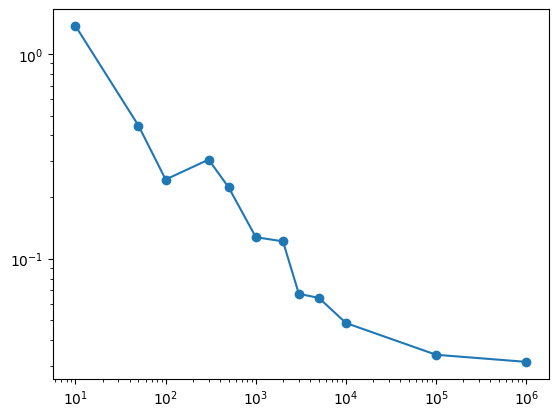

In [14]:
plt.loglog(M_,D,'o-')

In [11]:
D

[1.3716296553859946,
 0.446701468891895,
 0.2437624946859489,
 0.30487089947402196,
 0.22302903738333216,
 0.1274433313659212,
 0.12161573782401455,
 0.06739674390003052,
 0.06439083219484454,
 0.048532753175875326,
 0.03396393236303638,
 0.031359728906412636]

In [12]:
samples

tensor([[0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 3, 1, 4, 1]])

In [13]:
Pb

tensor([3, 1, 4, 1])